## Differential abundance by using ANCOM-BC

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statannotations.Annotator import Annotator
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from skbio.stats.composition import ancom, ancombc, struc_zero

plt.rcParams['font.size'] = 7
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42
# affects whiskers, medians, caps (all Line2D)
plt.rcParams['lines.linewidth'] = 0.6

In [69]:
## short name function
def extract_p_g_or_f(top: str) -> str:
    """
    Returns genus-level labels. If a genus annotation (g__) is available, 
    the genus name is used; otherwise, the nearest higher taxonomic rank (f__, o__, c__, or p__) 
    is used and labeled as "unclassified genus". 
    Entries labeled as "Others" are retained unchanged.
    """

    if top == "Others":
        return "Others"

    parts = [x.strip() for x in top.split(";") if x.strip()]

    tax_map = {}
    for part in parts:
        if "__" in part:
            rank, name = part.split("__", 1)
            tax_map[rank] = name.strip()


    g = tax_map.get("g", "")
    if g:
        return g


    for rank in ["f", "o", "c", "p"]:
        val = tax_map.get(rank, "")
        if val:
            return f"{val} unclassified genus"

    return top

## Data import
- Not Normalize!!


In [70]:
asv = 'data/2_preprocessed/prv10/prv10_ft.tsv'
mmi = 'data/mmi_fit_sepa.tsv'
otu_df = pd.read_csv(asv, sep='\t', index_col=0)
meta_df = pd.read_csv(mmi, sep='\t').set_index('#SampleID')
meta_df = meta_df.drop(columns=["MMI_fit"])


In [72]:
meta_df.head(2)

,Unnamed: 0,real_age,mmi,real_year,pred_year,Months,host_sex,Host_disease,location_disease,mean_age,Separation,Network,Group,mmibased
#SampleID,,,,,,,,,,,,,,
SRR23478195,0,18.0,67.06,1.0,5.09,18.0,female,Control,Control(IT),50.83,mmihigh,mmihigh,mmihigh,mmihigh
SRR23478196,1,18.0,45.70,1.0,3.31,18.0,male,Control,Control(IT),50.83,mmilow,mmilow,mmilow,mmilow


In [73]:
meta_df["mmibased"].value_counts()

mmibased
mmihigh    51
PIBD       49
mmilow     43
Name: count, dtype: int64

In [74]:
otu_df.head(2)

,d__Bacteria;__;__;__;__;__,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_725029;g__Escherichia,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae_A_595427;g__Sutterella,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Gemmiger_A_73129,d__Archaea;p__Methanobacteriota_A_1229;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter_A,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides_H_857956,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Chitinophagales;f__Chitinophagaceae;g__Hydrotalea,d__Bacteria;p__Actinomycetota;c__Actinomycetes;o__Actinomycetales;f__Bifidobacteriaceae;g__Bifidobacterium_388775,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lactobacillales;f__Enterococcaceae;g__Enterococcus_B,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Lachnospirales;f__Lachnospiraceae;g__Blautia_A_141780,...,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Eggerthellaceae;g__Gordonibacter,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae_A_595427;g__Parasutterella_564865,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae_A_595421;g__Oxalobacter,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Acutalibacteraceae;g__UMGS1071,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Acutalibacteraceae;g__Hydrogeniiclostridium,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Negativibacillus,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__QAKW01;g__,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Acutalibacteraceae;g__Clostridium_A_51961,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Monoglobales;f__Monoglobaceae;g__Monoglobus,d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Ruminiclostridium_E
#SampleID,,,,,,,,,,,,,,,,,,,,,
SRR23478191,0.0,120.0,0.0,0.0,0.0,189.0,0.0,23.0,317.0,6.0,...,0.0,328.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR23478195,1.0,132.0,0.0,1.0,1.0,2.0,0.0,154.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## change simply taxa name
### algorithm
1. if end g__, p__;f__;
2. if end f__, p__;o__;
3. if end o__, p__;c__;
4. else end g__A genus, p__;g__;


## ancombc activation
- FDR method: Bonferroni
    - if use other FDR Method: `p_adjust` parameter use
        - Holm-Bonferroni (default)
        - Benjamini-Hochberg ("bh", "fdr_bh" or "benjamini-hochberg")

### query
- Intercept is one of row.
- Singif == True mean signficant different any other group

## Visualization
- fc_cut = 0 ## it mean group different.
- rename Log2(FC): log2FC ## just simple.
- if `Signif` True value and log2fc > fc_cut 
    - mmilow_enriched
- if `Signif` True value and log2fc < fc_cut
    - mmihigh_enriched
- else
    - nonsignficant
- barplot

## Control all feature ANCOM-BC

In [78]:
meta_df["Group"] = meta_df.apply(
    lambda row: row["Separation"] if row["Host_disease"] == "Control" else row["Host_disease"],
    axis=1
)
meta_df = meta_df.reset_index()


otu_df = pd.read_csv(asv, sep='\t', index_col=0)

meta_df_control = meta_df[~meta_df["Group"].isin(["CD", "UC"])]
meta_df_control = meta_df_control.set_index("#SampleID")

otu_con_ids = set(otu_df.index)
meta_df_control_ids = set(meta_df_control.index)

common_control = sorted(otu_con_ids & meta_df_control_ids)

otu_con = otu_df.loc[common_control]
meta_df_con = meta_df_control.loc[common_control]

meta_con = meta_df_con.drop(columns={'Host_disease', 'host_sex'})



In [79]:
meta_con

,index,Unnamed: 0,real_age,mmi,real_year,pred_year,Months,location_disease,mean_age,Separation,Network,Group,mmibased
#SampleID,,,,,,,,,,,,,
SRR23478191,70,70,138.0,60.84,11.0,4.57,138.0,Control(IT),109.76,mmilow,mmilow,mmilow,mmilow
SRR23478195,0,0,18.0,67.06,1.0,5.09,18.0,Control(IT),50.83,mmihigh,mmihigh,mmihigh,mmihigh
SRR23478196,1,1,18.0,45.70,1.0,3.31,18.0,Control(IT),50.83,mmilow,mmilow,mmilow,mmilow
SRR23478197,2,2,18.0,39.73,1.0,2.81,18.0,Control(IT),50.83,mmilow,mmilow,mmilow,mmilow
SRR23478198,3,3,30.0,57.06,2.0,4.25,30.0,Control(IT),56.42,mmihigh,mmihigh,mmihigh,mmilow
...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRR23478290,91,91,186.0,122.94,15.0,9.75,186.0,Control(IT),122.46,mmihigh,mmihigh,mmihigh,mmihigh
SRR23478291,92,92,198.0,124.33,16.0,9.86,198.0,Control(IT),124.33,mmihigh,mmihigh,mmihigh,mmihigh
SRR23478292,77,77,138.0,122.25,11.0,9.69,138.0,Control(IT),109.76,mmihigh,mmihigh,mmihigh,mmihigh


In [80]:
con_short_names = {col: extract_p_g_or_f(col) for col in otu_con.columns}

con_short_names

{'d__Bacteria;__;__;__;__;__': 'd__Bacteria;__;__;__;__;__',
 'd__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_725029;g__Escherichia': 'Escherichia',
 'd__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Burkholderiales;f__Burkholderiaceae_A_595427;g__Sutterella': 'Sutterella',
 'd__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Oscillospirales;f__Ruminococcaceae;g__Gemmiger_A_73129': 'Gemmiger_A_73129',
 'd__Archaea;p__Methanobacteriota_A_1229;c__Methanobacteria;o__Methanobacteriales;f__Methanobacteriaceae;g__Methanobrevibacter_A': 'Methanobrevibacter_A',
 'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides_H_857956': 'Bacteroides_H_857956',
 'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Chitinophagales;f__Chitinophagaceae;g__Hydrotalea': 'Hydrotalea',
 'd__Bacteria;p__Actinomycetota;c__Actinomycetes;o__Actinomycetales;f__Bifidobacteriaceae;g__Bifidobacterium_388775': 'Bifido

In [81]:
anc_control = ancombc(otu_con + 1, meta_con, formula="mmibased")
anc_control.head(10)

Log2(FC)  \
FeatureID                                          Covariate                      
d__Bacteria;__;__;__;__;__                         Intercept          -0.197476   
                                                   mmibased[T.mmilow] -0.062170   
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac... Intercept           2.818337   
                                                   mmibased[T.mmilow]  0.417236   
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac... Intercept          -0.208491   
                                                   mmibased[T.mmilow] -0.379743   
d__Bacteria;p__Bacillota_A_368345;c__Clostridia... Intercept           3.844041   
                                                   mmibased[T.mmilow] -0.972943   
d__Archaea;p__Methanobacteriota_A_1229;c__Metha... Intercept           0.211783   
                                                   mmibased[T.mmilow] -0.338453   

                                                                             SE  \
FeatureID                                          Covariate                      
d__Bacteria;__;__;__;__;__                         Intercept           0.102853   
                                                   mmibased[T.mmilow]  0.149313   
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac... Intercept           0.350028   
                                                   mmibased[T.mmilow]  0.481930   
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac... Intercept           0.121080   
                                                   mmibased[T.mmilow]  0.130458   
d__Bacteria;p__Bacillota_A_368345;c__Clostridia... Intercept           0.257285   
                                                   mmibased[T.mmilow]  0.458598   
d__Archaea;p__Methanobacteriota_A_1229;c__Metha... Intercept           0.253021   
                                                   mmibased[T.mmilow]  0.341823   

                                                                               W  \
FeatureID                                          Covariate                       
d__Bacteria;__;__;__;__;__                         Intercept           -1.919975   
                                                   mmibased[T.mmilow]  -0.416377   
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac... Intercept            8.051739   
                                                   mmibased[T.mmilow]   0.865760   
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac... Intercept           -1.721928   
                                                   mmibased[T.mmilow]  -2.910845   
d__Bacteria;p__Bacillota_A_368345;c__Clostridia... Intercept           14.940804   
                                                   mmibased[T.mmilow]  -2.121558   
d__Archaea;p__Methanobacteriota_A_1229;c__Metha... Intercept            0.837014   
                                                   mmibased[T.mmilow]  -0.990141   

                                                                             pvalue  \
FeatureID                                          Covariate                          
d__Bacteria;__;__;__;__;__                         Intercept           5.486102e-02   
                                                   mmibased[T.mmilow]  6.771340e-01   
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac... Intercept           8.162610e-16   
                                                   mmibased[T.mmilow]  3.866219e-01   
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac... Intercept           8.508261e-02   
                                                   mmibased[T.mmilow]  3.604526e-03   
d__Bacteria;p__Bacillota_A_368345;c__Clostridia... Intercept           1.788038e-50   
                                                   mmibased[T.mmilow]  3.387488e-02   
d__Archaea;p__Methanobacteriota_A_1229;c__Metha... Intercept           4.025845e-01   
                                                   mmibased[T.mmilow]  3.221050e-01   

                       

In [82]:
asd = anc_control.query('Covariate != "Intercept" & Signif == True').round(3)

asd.reset_index(inplace=True)
asd_save = asd.copy()
asd_save["FeatureID"] = asd_save["FeatureID"].replace(con_short_names)
asd_save
asd_save.to_csv("data/3_results/4_ancombc/ancombc_control.tsv", sep='\t')

/tmp/ipykernel_375767/384920690.py:1: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  asd = anc_control.query('Covariate != "Intercept" & Signif == True').round(3)


/tmp/ipykernel_375767/464227957.py:73: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


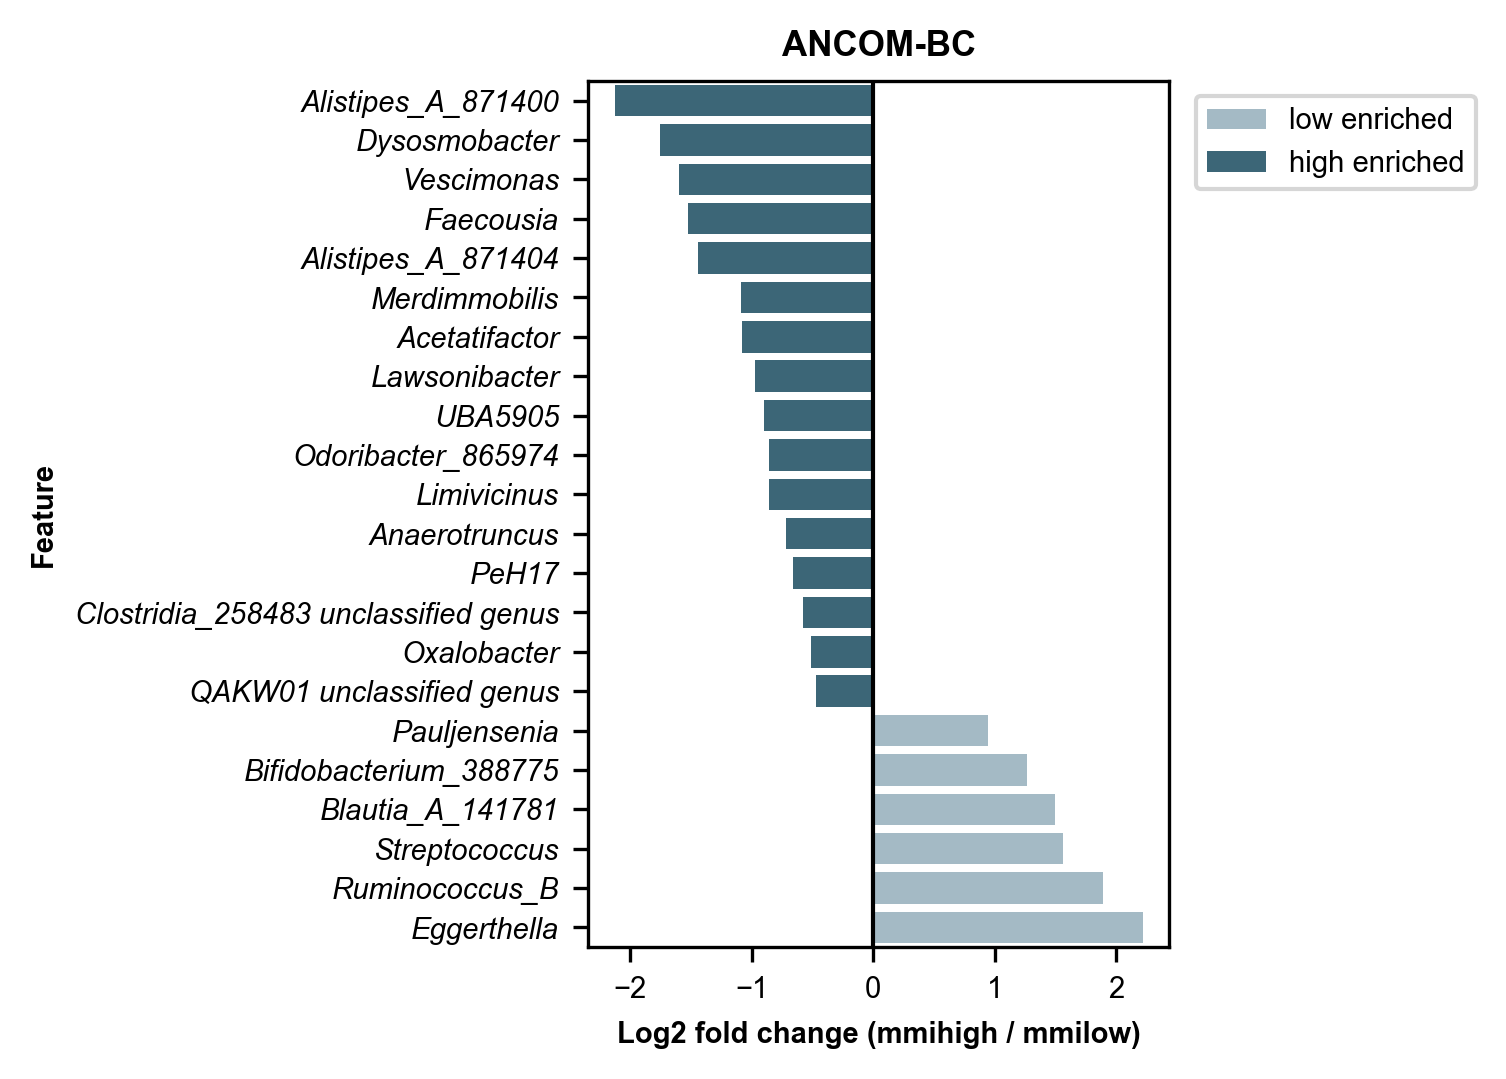

In [ ]:
vi = anc_control.reset_index()

low_rows = vi[vi["Covariate"] == "mmibased[T.mmilow]"].copy()

low_rows.rename(columns={"Log2(FC)":"log2FC"},inplace=True)

fc_cut = 0

def label_cat(row):
    if row["Signif"] and row["log2FC"] > fc_cut:
        return "mmilow_enriched"
    if row["Signif"] and row["log2FC"] < -fc_cut:
        return "mmihigh_enriched"
    else:
        return "nonsignficant"
    
low_rows["category"] = low_rows.apply(label_cat, axis=1)   

low_rows["FeatureID"] = low_rows["FeatureID"].replace(con_short_names)

top = (
    low_rows
    .sort_values("log2FC", key=lambda s: s.abs(), ascending=False)
)

top_sign = top[top['category'] != 'nonsignficant']
top_sign = top_sign[top_sign['FeatureID'] != 'shannon']

order_feat = top_sign.sort_values("log2FC")["FeatureID"]

palette = {
    "mmilow_enriched": "#9fbccaa0",    
    "mmihigh_enriched": "#326a81a0",    
    "nonsignficant": "lightgray",
}
N = 30
plt.figure(figsize=(2.5, 3.75), dpi=300)
ax = sns.barplot(
    data=top_sign,
    x="log2FC",
    y="FeatureID",
    hue="category",
    palette=palette,
    order=order_feat
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Log2 fold change (mmihigh / mmilow)", fontweight='bold')
ax.set_ylabel("Feature", fontweight='bold')
for tick in ax.get_yticklabels():
    tick.set_fontstyle("italic")



handles, labels = ax.get_legend_handles_labels()

label_map = {
    "mmilow_enriched": "low enriched",
    "mmihigh_enriched": "high enriched",
    "nonsignficant": "nonsignificant"
}

new_labels = [label_map.get(lbl, lbl) for lbl in labels]

ax.legend(
    handles,
    new_labels,
    frameon=True,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.title("ANCOM-BC", fontweight='bold')
plt.tight_layout()
plt.savefig("figure/5_ancombc/all_ancombc_control_sign.pdf", dpi=300, bbox_inches="tight")

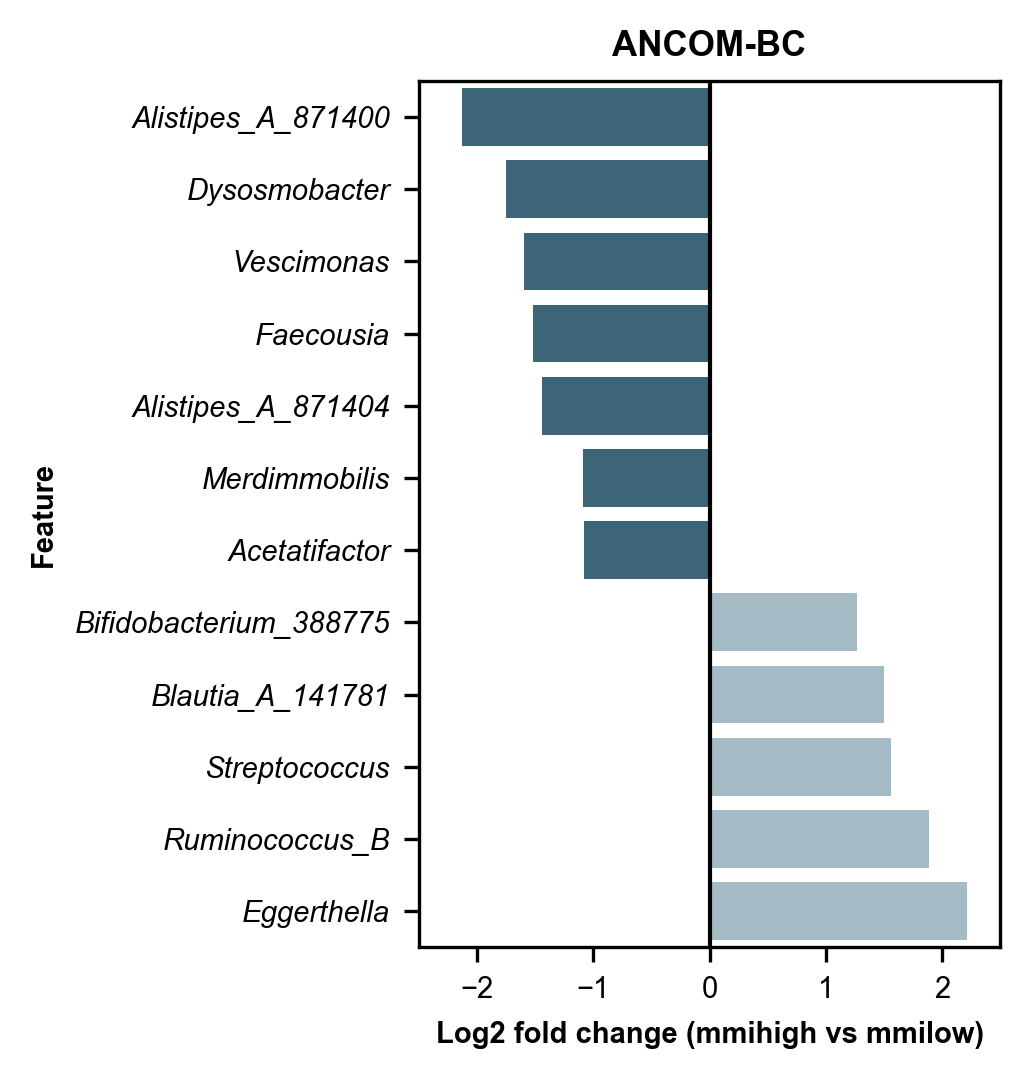

In [84]:
vi = anc_control.reset_index()

low_rows = vi[vi["Covariate"] == "mmibased[T.mmilow]"].copy()

low_rows.rename(columns={"Log2(FC)":"log2FC"},inplace=True)

fc_cut = 1

def label_cat(row):
    if row["Signif"] and row["log2FC"] > fc_cut:
        return "mmilow_enriched"
    if row["Signif"] and row["log2FC"] < -fc_cut:
        return "mmihigh_enriched"
    else:
        return "nonsignficant"
    
low_rows["category"] = low_rows.apply(label_cat, axis=1)   

low_rows["FeatureID"] = low_rows["FeatureID"].replace(con_short_names)

top = (
    low_rows
    .sort_values("log2FC", key=lambda s: s.abs(), ascending=False)
)

top_sign = top[top['category'] != 'nonsignficant']
top_sign = top_sign[top_sign['FeatureID'] != 'shannon']

order_feat = top_sign.sort_values("log2FC")["FeatureID"]

palette = {
    "mmilow_enriched": "#9fbccaa0",      
    "mmihigh_enriched": "#326a81a0",     
    "nonsignficant": "lightgray",
}
N = 30
plt.figure(figsize=(2.5, 3.75), dpi=300)
ax = sns.barplot(
    data=top_sign,
    x="log2FC",
    y="FeatureID",
    hue="category",
    palette=palette,
    order=order_feat
)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlim(-2.5,2.5)
ax.set_xlabel("Log2 fold change (mmihigh vs mmilow)", fontweight='bold')
ax.set_ylabel("Feature", fontweight='bold')
for tick in ax.get_yticklabels():
    tick.set_fontstyle("italic")
ax.get_legend().remove()

plt.title("ANCOM-BC", fontweight='bold')
plt.savefig("figure/5_ancombc/cutoff_ancombc_sign.pdf", dpi=300, bbox_inches="tight")